***Práctica 1. Configuración y Generación del Dato RAW***: Esta práctica genera el escenario. Para garantizar que los tiempos de ejecución sean de un par de segundos, usaremos un modelo simplificado matemático en numpy que recrea el eco de los blancos.


Lo que verán: Un gráfico 2D lleno de ruido visual bidimensional donde la energía de los 3 blancos (3 barcos en linea)está completamente dispersada.

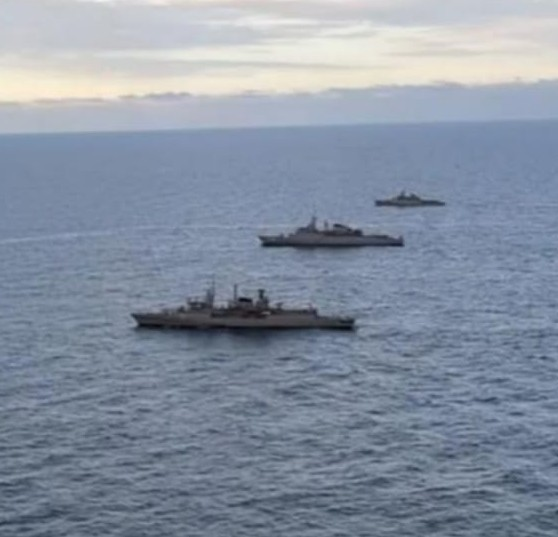

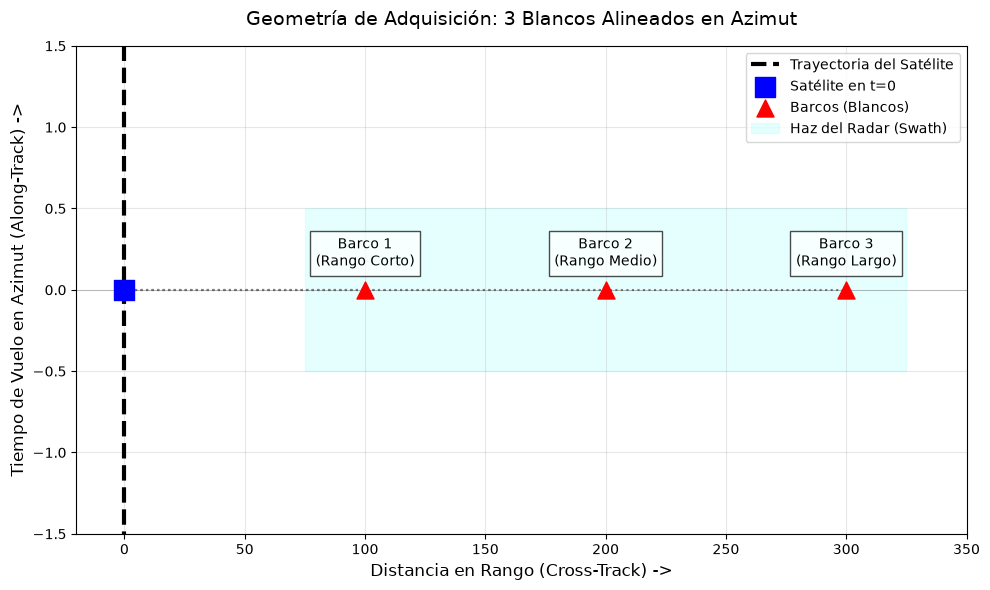

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de la figura
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Dibujar la trayectoria del satélite (Eje Azimut)
ax.plot([0, 0], [-2, 2], color='black', linewidth=3, linestyle='--', label='Trayectoria del Satélite')
# Representación del satélite en el instante de iluminación (Azimut = 0)
ax.scatter([0], [0], color='blue', s=200, marker='s', label='Satélite en t=0', zorder=5)

# 2. Dibuja los 3 Barcos (Blancos Puntuales)
# Coordenadas: [Rango (x), Azimut (y)]
barcos_rango = [100, 200, 300]
barcos_azimut = [0, 0, 0]

ax.scatter(barcos_rango, barcos_azimut, color='red', s=150, marker='^', label='Barcos (Blancos)', zorder=5)

# Etiquetas para los barcos
ax.text(100, 0.15, 'Barco 1\n(Rango Corto)', ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
ax.text(200, 0.15, 'Barco 2\n(Rango Medio)', ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
ax.text(300, 0.15, 'Barco 3\n(Rango Largo)', ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

# 3. Dibuja el haz del radar (Iluminación)
haz_y = np.linspace(-0.5, 0.5, 100)
haz_x = np.full_like(haz_y, 325)
ax.fill_betweenx(haz_y, 75, haz_x, color='cyan', alpha=0.1, label='Haz del Radar (Swath)')

# 4. Líneas de distancia (Rango)
for r in barcos_rango:
    ax.plot([0, r], [0, 0], color='gray', linestyle=':', linewidth=1.5)

# Configuración estética
ax.set_xlim(-20, 350)
ax.set_ylim(-1.5, 1.5)
ax.set_title('Geometría de Adquisición: 3 Blancos Alineados en Azimut', fontsize=14, pad=15)
ax.set_xlabel('Distancia en Rango (Cross-Track) ->', fontsize=12)
ax.set_ylabel('Tiempo de Vuelo en Azimut (Along-Track) ->', fontsize=12)
ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

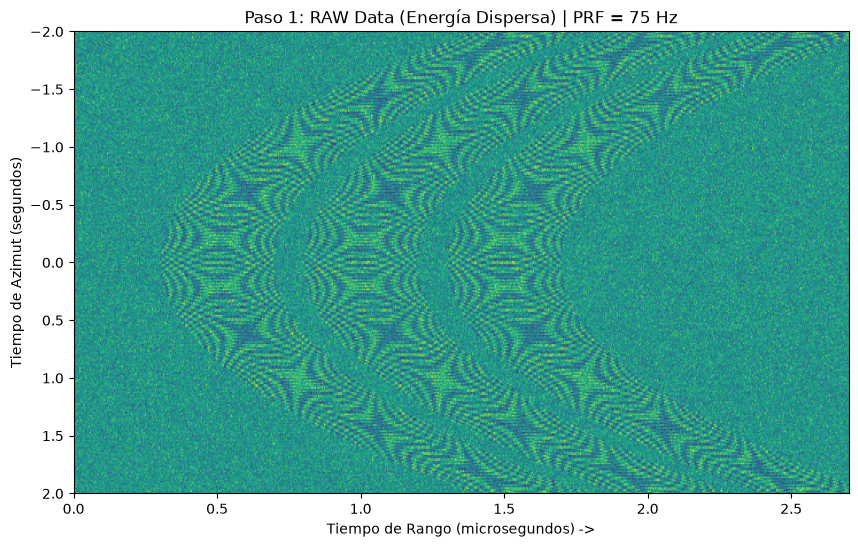

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PARÁMETROS FÍSICOS DEL RADAR ---
c = 3e8              # Velocidad de la luz
fc = 5.3e9           # Frecuencia portadora (Banda C)
v = 7000             # Velocidad del satélite (m/s)
H = 600e3            # Altura del satélite (m)
lambda_c = c / fc

# --- 2. PARÁMETROS DE LA SEÑAL (RANGO) ---

# ====================================================================
# --- PARÁMETRO DE LABORATORIO (Rango) ---
Bw_rango = 80e6      # Ancho de banda (4 MHz,límite)# Probar con: 80e6 (Buena res.), 1e6(Persida total res.)
# La frecuencia viene setteada en el circuito, es fija
# Es la frecuencia del chirp
# a mayor ancho de banda, menor ancho de pulso, por lo tanto puedo captar/transportar más información
# ====================================================================


tau = 0.4e-6         # Duración del pulso (0.4 microsegundos)
K = Bw_rango / tau   # Tasa del Chirp (Hz/s)
Fs_rango = 250e6     # Frecuencia de muestreo en Rango (250 MHz)

# ====================================================================
# --- PARÁMETRO DE LABORATORIO (AZIMUT) ---
PRF_Hz = 75       # Probar con: 75 (Aliasing), 150 (Límite), 600 (Limpio)
# PRF --> cantidad de pulsos
# ====================================================================

# Calculamos las grillas automáticamente en base a tiempos de observación y frecuencias
tiempo_obs_azimut = 4.0
tiempo_obs_rango = 2.7e-6

num_muestras_azimut = int(PRF_Hz * tiempo_obs_azimut)
num_muestras_rango = int(tiempo_obs_rango * Fs_rango)

# --- 3. GRILLA ESTRICTA: Filas = Azimut, Columnas = Rango ---
t_azimut = np.linspace(-2, 2, num_muestras_azimut)
t_rango = np.linspace(0, tiempo_obs_rango, num_muestras_rango)

Taz, Tr = np.meshgrid(t_azimut, t_rango, indexing='ij')

# --- 4. DEFINICIÓN DE LOS BLANCOS (Alineados en Azimut) ---
blancos = [
    [0.0, 0.5e-6],   # Barco cercano
    [0.0, 1.0e-6],   # Barco en medio
    [0.0, 1.5e-6]    # Barco lejano
]

# --- 5. GENERACIÓN DEL DATO RAW ---
raw_data = np.zeros_like(Taz, dtype=complex)

for az_t, rg_t in blancos:
    for i, t_a in enumerate(t_azimut):
        R_t = np.sqrt(H**2 + (v * (t_a - az_t))**2) - H
        retraso_doppler = 2 * R_t / c

        # Usamos explícitamente K y tau para el Chirp
        pulso = np.exp(1j * np.pi * K * (t_rango - rg_t - retraso_doppler)**2)
        envolvente = np.abs(t_rango - rg_t - retraso_doppler) < (tau / 2)
        fase_doppler = np.exp(-1j * 4 * np.pi * R_t / lambda_c)

        raw_data[i, :] += pulso * envolvente * fase_doppler

# Añadir ruido térmico
ruido = (np.random.randn(*raw_data.shape) + 1j * np.random.randn(*raw_data.shape)) * 0.5
raw_data += ruido

# --- PLOT: DATO RAW ---
plt.figure(figsize=(10, 6))
rango_us = t_rango * 1e6

plt.imshow(np.real(raw_data), aspect='auto', cmap='viridis',
           extent=[rango_us[0], rango_us[-1], t_azimut[-1], t_azimut[0]])
plt.title(f'Paso 1: RAW Data (Energía Dispersa) | PRF = {PRF_Hz} Hz')
plt.xlabel('Tiempo de Rango (microsegundos) ->')
plt.ylabel('Tiempo de Azimut (segundos)')
plt.show()

***Práctica 2. Compresión en Rango***:
Aplicamos una Transformada Rápida de Fourier (FFT) para comprimir el pulso a lo ancho.


Lo que verán: El gráfico se actualiza mostrando las hipérbolas/parábolas de migración con la energía en Rango ya focalizada.

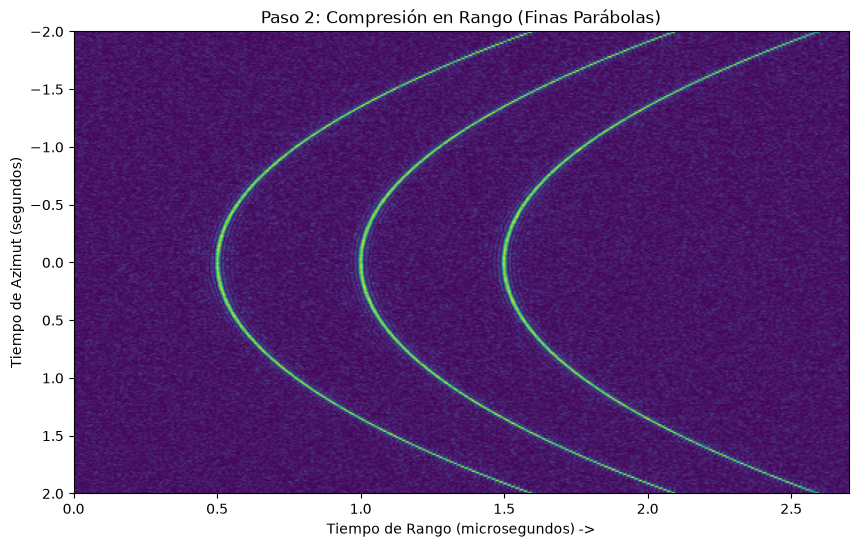

In [27]:
# --- 6. COMPRESIÓN EN RANGO ---
rango_comprimido = np.zeros_like(raw_data)

# Creamos el tiempo de referencia usando las muestras exactas de rango
t_ref = np.linspace(-tiempo_obs_rango/2, tiempo_obs_rango/2, num_muestras_rango)

# Usamos las variables físicas K y tau definidas en la Celda 1
pulso_referencia = np.exp(1j * np.pi * K * t_ref**2) * (np.abs(t_ref) < (tau / 2))

# Centrado estricto del filtro
filtro_espectro = np.fft.fft(np.fft.ifftshift(pulso_referencia))

for i in range(raw_data.shape[0]):
    espectro_rango = np.fft.fft(raw_data[i, :])
    rango_comprimido[i, :] = np.fft.ifft(espectro_rango * np.conj(filtro_espectro))

# --- PLOT: COMPRESIÓN EN RANGO ---
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(rango_comprimido), aspect='auto', cmap='viridis',
           extent=[rango_us[0], rango_us[-1], t_azimut[-1], t_azimut[0]])
plt.title('Paso 2: Compresión en Rango (Finas Parábolas)')
plt.xlabel('Tiempo de Rango (microsegundos) ->')
plt.ylabel('Tiempo de Azimut (segundos)')
plt.show()

***Practica 3. Corrección de Migración de Celda de Rango (RCMC)***:
Desplazamos los píxeles matemáticamente para enderezar las curvas.


Lo que verán: Las curvas del gráfico anterior se enderezan perfectamente. NOTA: El método de corrección de la migración por rango es en el espacio temporal, muy básico y solo sirve como ejemplo didáctico. En imagenes reales, la corrección se hace en frecuencia.

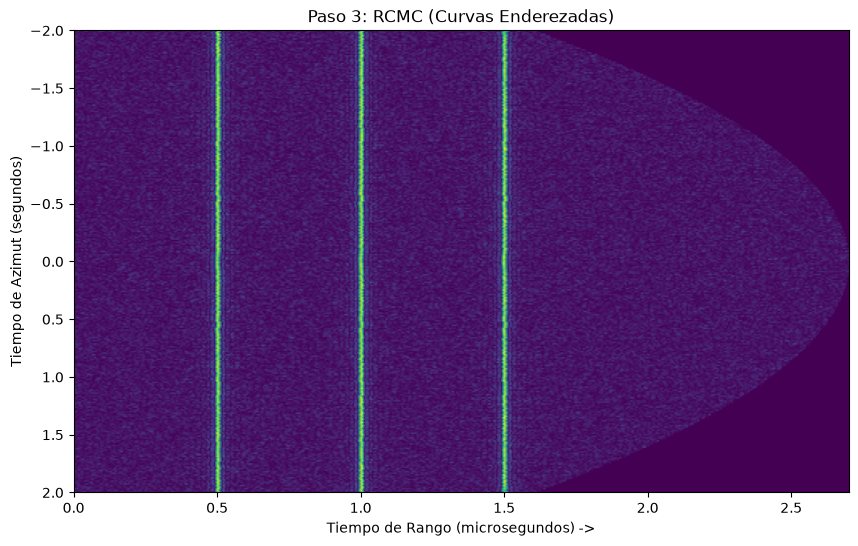

In [28]:
# --- 7. RCMC (Corrección Geométrica) ---
rcmc_data = np.zeros_like(rango_comprimido)

# Corregimos fila por fila, empujando la energía hacia la izquierda (menor rango)
for i, t_a in enumerate(t_azimut):
    curvatura = np.sqrt(H**2 + (v * t_a)**2) - H
    # Cuántas columnas (bins) debemos desplazar
    desplazamiento_bins = int((2 * curvatura / c) / (t_rango[1] - t_rango[0]))

    if desplazamiento_bins > 0:
        # Desplazamos los datos a lo largo del eje de Rango (columnas)
        rcmc_data[i, :-desplazamiento_bins] = rango_comprimido[i, desplazamiento_bins:]
    else:
        rcmc_data[i, :] = rango_comprimido[i, :]

# --- PLOT: RCMC ---
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(rcmc_data), aspect='auto', cmap='viridis',
           extent=[rango_us[0], rango_us[-1], t_azimut[-1], t_azimut[0]])
plt.title('Paso 3: RCMC (Curvas Enderezadas)')
plt.xlabel('Tiempo de Rango (microsegundos) ->')
plt.ylabel('Tiempo de Azimut (segundos)')
plt.show()

***Práctica 4: Compresión en Azimut (El Píxel Final)***:
El paso final procesa la historia Doppler a lo largo de las columnas ya enderezadas.
Lo que verán: El ruido desaparece y surgen 3 puntos brillantes perfectos. La imagen SAR está enfocada.

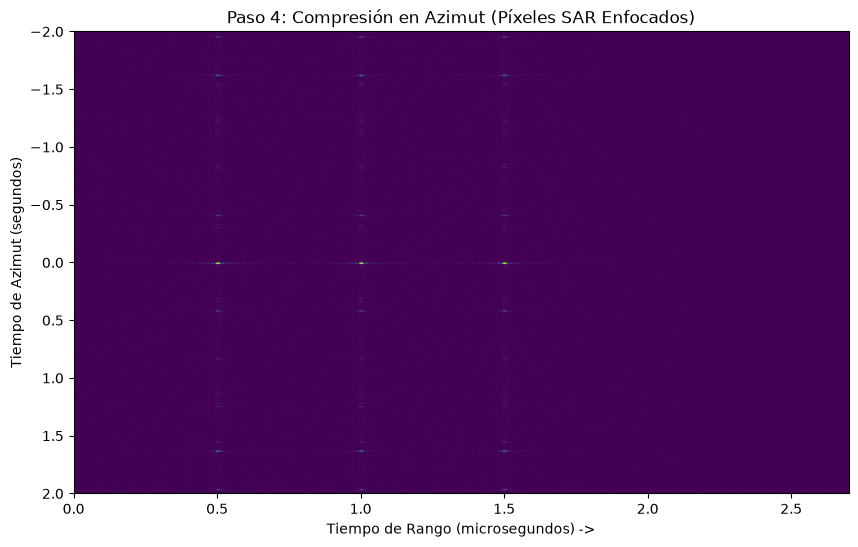

In [30]:
# --- 8. COMPRESIÓN EN AZIMUT ---
imagen_final = np.zeros_like(rcmc_data)

# Recreamos la historia de fase Doppler
R_ref = np.sqrt(H**2 + (v * t_azimut)**2) - H
filtro_azimut = np.exp(-1j * 4 * np.pi * R_ref / lambda_c)

# Alineamos el centro geométrico del filtro
espectro_filtro_az = np.fft.fft(np.fft.ifftshift(filtro_azimut))

# Compresión a lo largo del Azimut (filas)
for j in range(rcmc_data.shape[1]):
    espectro_azimut = np.fft.fft(rcmc_data[:, j])
    imagen_final[:, j] = np.fft.ifft(espectro_azimut * np.conj(espectro_filtro_az))

# --- PLOT: IMAGEN ENFOCADA ---
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(imagen_final), aspect='auto', cmap='viridis',
           extent=[rango_us[0], rango_us[-1], t_azimut[-1], t_azimut[0]])
plt.title('Paso 4: Compresión en Azimut (Píxeles SAR Enfocados)')
plt.xlabel('Tiempo de Rango (microsegundos) ->')
plt.ylabel('Tiempo de Azimut (segundos)')
plt.show()

La distancia entre los objetos están en el límite del ancho de banda. La señal no logre a separarlos. Tenemos dos picos juntos, pero sin un valle = 0 entre ellos

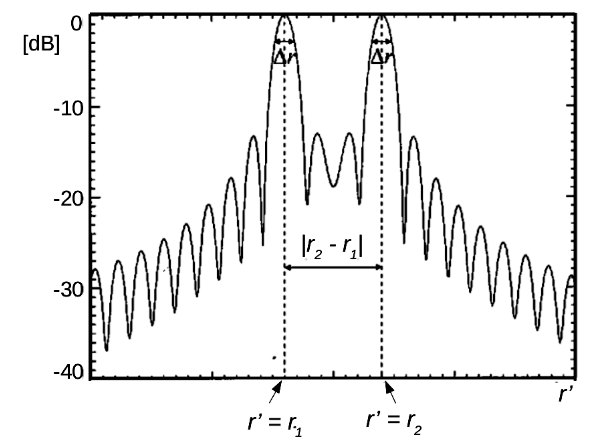

***El problema visual:***
El radar no "ve" la luz como nosotros. Un reflector puntual (como el casco metálico de un barco) devuelve tanta energía concentrada que su amplitud numérica es colosal frente al "ruido" o fondo vacío. Al graficar esto de forma lineal (como estamos haciendo), Python asigna el color brillante al máximo valor, y el resto del fondo queda aplastado a negro.

La solución: En radar siempre visualizamos las imágenes finales en Decibelios (dB). Esto comprime matemáticamente la escala para que nuestros ojos puedan ver los blancos brillantes sin que el fondo oscuro desaparezca por completo.



/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:853: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/matplotlib/axes/_axes.py:7518: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


(array([4.00639e+05, 2.53500e+03, 1.12900e+03, 3.44000e+02, 2.50000e+01,
        1.70000e+01, 1.76000e+02, 4.20000e+01, 4.30000e+01, 5.00000e+01]),
 array([-4184.0740417 ,  2191.41251221,  8566.89906612, 14942.38562003,
        21317.87217394, 27693.35872785, 34068.84528176, 40444.33183567,
        46819.81838958, 53195.30494349, 59570.7914974 ]),
 <BarContainer object of 10 artists>)

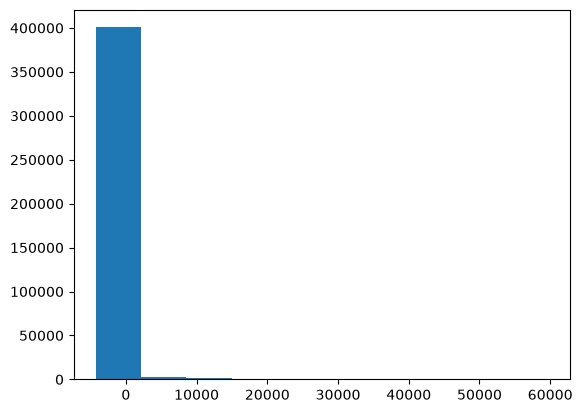

In [8]:
plt.hist(imagen_final.flatten())

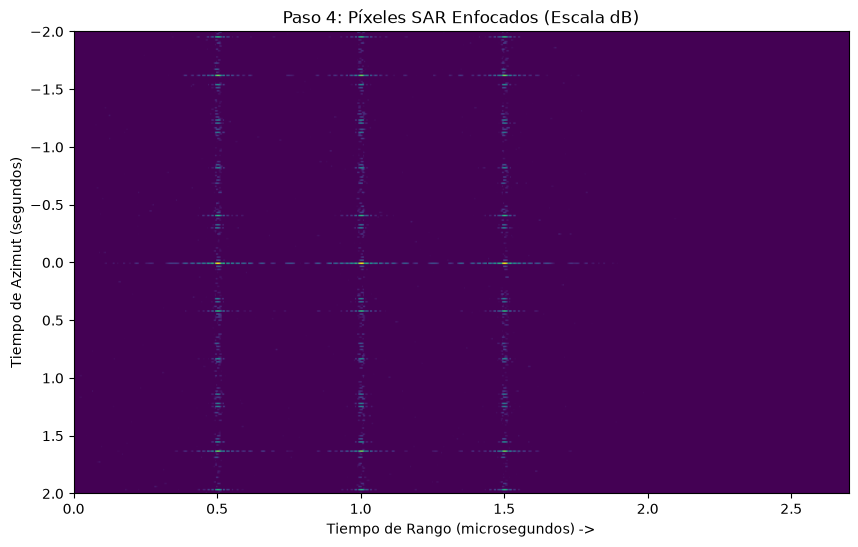

In [31]:
# --- PLOT: IMAGEN ENFOCADA (ESCALA LOGARÍTMICA) ---
# Pasamos la magnitud a Decibelios (sumamos 1e-10 para evitar logaritmo de cero)
imagen_dB = 20 * np.log10(np.abs(imagen_final) + 1e-10)

# Calculamos el valor máximo para anclar nuestra escala de colores
max_dB = np.max(imagen_dB)

plt.figure(figsize=(10, 6))
# Usamos vmin y vmax para mostrar solo el rango dinámico superior (ej. los 40 dB más fuertes)
plt.imshow(imagen_dB, aspect='auto', cmap='viridis',
           extent=[rango_us[0], rango_us[-1], t_azimut[-1], t_azimut[0]],
           vmin=max_dB - 40, vmax=max_dB)

plt.title('Paso 4: Píxeles SAR Enfocados (Escala dB)')
plt.xlabel('Tiempo de Rango (microsegundos) ->')
plt.ylabel('Tiempo de Azimut (segundos)')
plt.show()

(array([1.40000e+01, 1.88000e+02, 1.87500e+03, 2.15270e+04, 1.51541e+05,
        1.98211e+05, 2.39980e+04, 4.81200e+03, 2.34800e+03, 4.86000e+02]),
 array([-10.1490979 ,   0.41587864,  10.98085517,  21.54583171,
         32.11080825,  42.67578479,  53.24076132,  63.80573786,
         74.3707144 ,  84.93569094,  95.50066747]),
 <BarContainer object of 10 artists>)

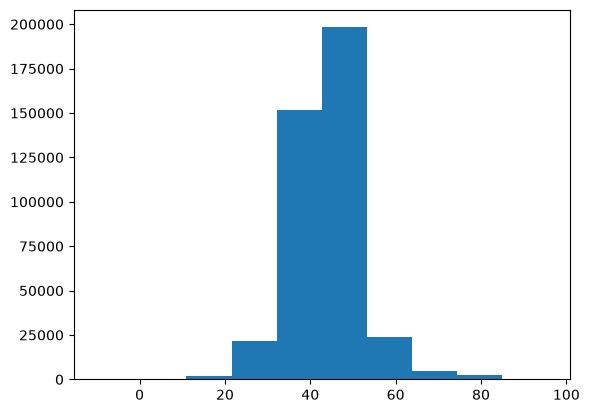

In [7]:
plt.hist(imagen_dB.flatten())

Zoom para poder ver los point targets debido a la alta resolucion lograda con el cambio de PRF:

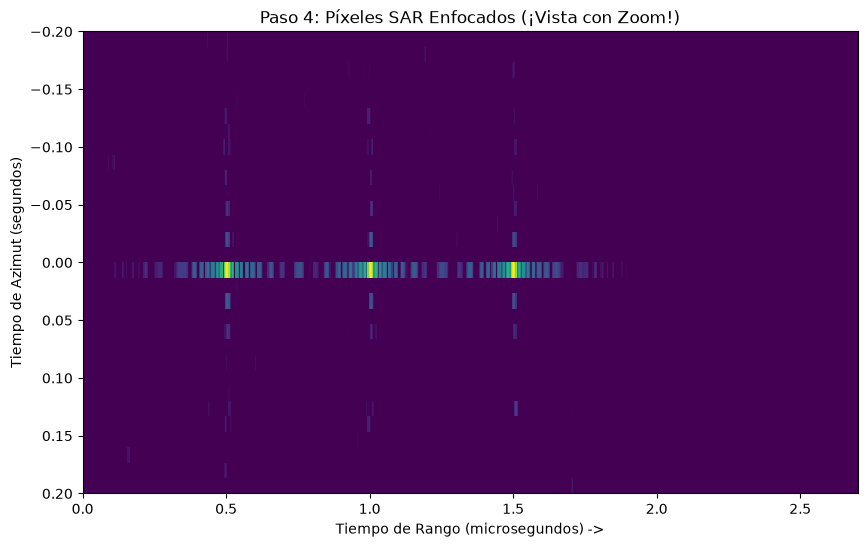

In [32]:
# --- PLOT: IMAGEN ENFOCADA (ESCALA LOGARÍTMICA CON ZOOM) ---
imagen_dB = 20 * np.log10(np.abs(imagen_final) + 1e-10)
max_dB = np.max(imagen_dB)

plt.figure(figsize=(10, 6))

# Agregamos interpolation='nearest' para obligar a Python a NO promediar los píxeles brillantes
plt.imshow(imagen_dB, aspect='auto', cmap='viridis',
           extent=[rango_us[0], rango_us[-1], t_azimut[-1], t_azimut[0]],
           vmin=max_dB - 40, vmax=max_dB, interpolation='nearest')

plt.title('Paso 4: Píxeles SAR Enfocados (¡Vista con Zoom!)')
plt.xlabel('Tiempo de Rango (microsegundos) ->')
plt.ylabel('Tiempo de Azimut (segundos)')

# ==========================================
# Limitamos la vista para ver solo el segundo central del vuelo
plt.ylim(0.2, -0.2)
# ==========================================

plt.show()

***Práctico 5: Análisis de la IRF (Cortes en Rango y Azimut):***
Al hacer un corte transversal sobre uno de los píxeles brillantes, podrán ver físicamente la forma de la matemática que discutimos en la teoría: la famosa función Sinc . Verán el lóbulo principal (que define la resolución) y los lóbulos secundarios (que representan el "ruido" que se fuga del blanco).



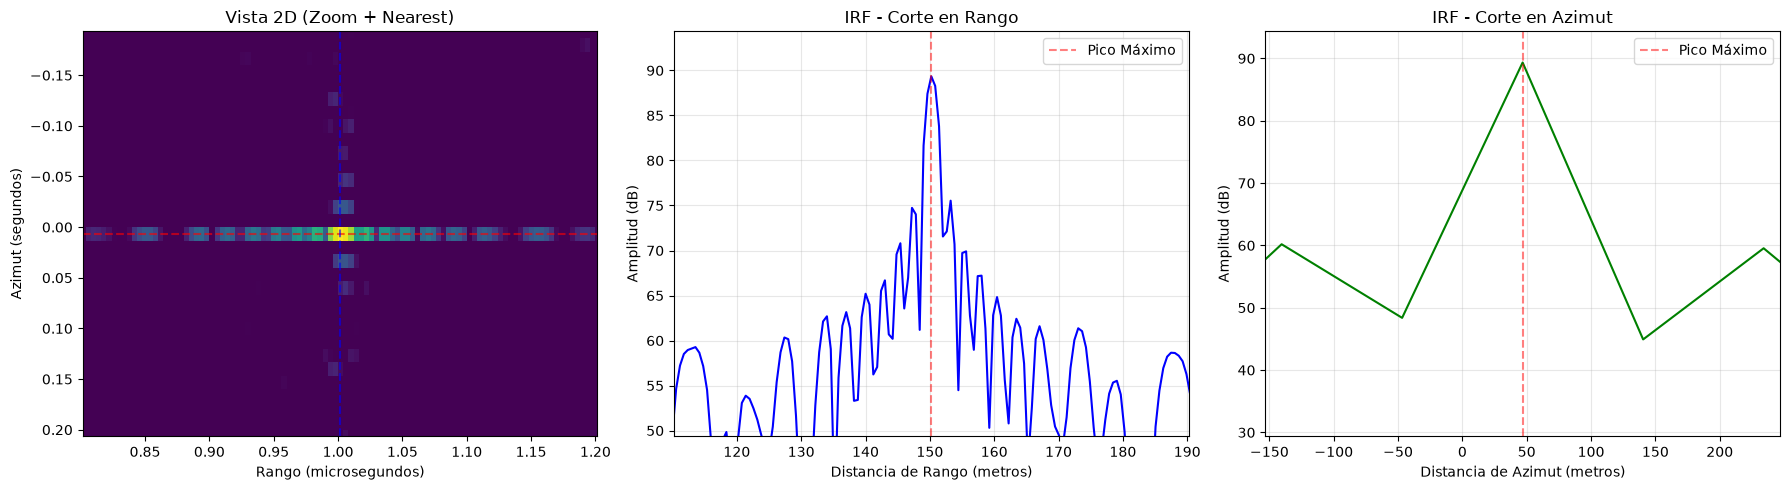

In [33]:
# --- 8. ANÁLISIS DE LA FUNCIÓN DE RESPUESTA AL IMPULSO (IRF) ---

# 1. Buscamos las coordenadas del píxel más brillante en la matriz
idx_az, idx_rg = np.unravel_index(np.argmax(np.abs(imagen_final)), imagen_final.shape)

# 2. Extraemos los perfiles 1D en dB
corte_azimut = imagen_dB[:, idx_rg]
corte_rango = imagen_dB[idx_az, :]

# ====================================================================
# 3. CONVERSIÓN FÍSICA A METROS
rango_metros = t_rango * c / 2      # Distancia real (Slant Range)
azimut_metros = t_azimut * v        # Distancia real de vuelo
# ====================================================================

# --- PLOT: TABLERO IRF (3 PANELES) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel Izquierdo: Imagen 2D (Sigue en tiempos para referencia) ---
max_dB = np.max(imagen_dB)
ax1.imshow(imagen_dB, aspect='auto', cmap='viridis',
           extent=[rango_us[0], rango_us[-1], t_azimut[-1], t_azimut[0]],
           vmin=max_dB - 40, vmax=max_dB, interpolation='nearest')

ax1.set_xlim(rango_us[idx_rg] - 0.2, rango_us[idx_rg] + 0.2)
ax1.set_ylim(t_azimut[idx_az] + 0.2, t_azimut[idx_az] - 0.2)
ax1.axhline(y=t_azimut[idx_az], color='red', linestyle='--', alpha=0.6)
ax1.axvline(x=rango_us[idx_rg], color='blue', linestyle='--', alpha=0.6)
ax1.set_title('Vista 2D (Zoom + Nearest)')
ax1.set_xlabel('Rango (microsegundos)')
ax1.set_ylabel('Azimut (segundos)')

# --- Panel Central: Corte en Rango (AHORA EN METROS) ---
ax2.plot(rango_metros, corte_rango, color='blue', linewidth=1.5)
ax2.axvline(x=rango_metros[idx_rg], color='red', linestyle='--', alpha=0.5, label='Pico Máximo')
# Hacemos un zoom de +/- 40 metros alrededor del blanco
ax2.set_xlim(rango_metros[idx_rg] - 40, rango_metros[idx_rg] + 40)
ax2.set_ylim(max_dB - 40, max_dB + 5)
ax2.set_title('IRF - Corte en Rango')
ax2.set_xlabel('Distancia de Rango (metros)')
ax2.set_ylabel('Amplitud (dB)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# --- Panel Derecho: Corte en Azimut (AHORA EN METROS) ---
ax3.plot(azimut_metros, corte_azimut, color='green', linewidth=1.5)
ax3.axvline(x=azimut_metros[idx_az], color='red', linestyle='--', alpha=0.5, label='Pico Máximo')
# Hacemos un zoom de +/- 200 metros alrededor del blanco
ax3.set_xlim(azimut_metros[idx_az] - 200, azimut_metros[idx_az] + 200)
ax3.set_ylim(max_dB - 60, max_dB + 5)
ax3.set_title('IRF - Corte en Azimut')
ax3.set_xlabel('Distancia de Azimut (metros)')
ax3.set_ylabel('Amplitud (dB)')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

NOTA

- La resolución en rango y azimut se define como ladistancia entre +/- 3 dB desde el pico de la amplitud
- La distancia (relativa) se calcula a partir del t y la velocidad del sonido
- La resolución en azimut depende de la PRF, ya que esto define la cantidad de líneas, y por ende el pixel spacing en esta dimensión


Definicion PRF

PRF = 1886         # Tasa de repetición de pulsos [Hz]

La imagen cruda es una matriz de pulsos (lines) y muestras (samples)

lines = 16974           # Número de líneas (filas) en la imagen

Parámetros previos

pixel_spacing_az = Vs / PRF

wl = C / fc                       # Longitud de onda [m]

R_mid = (R_near + R_far)/2            # Distancia promedio al centro de la imagen [m]


Resolución en Azimut sin procesar (Radar de Apertura Real - RAR)

res_azimuth_rar = R_mid*wl/La


Resolución en Azimut procesada (Radar de Apertura Sintética - SAR)

res_azimuth_sar = La / 2


In [ ]:
- La PRF se traduce en la cantidad de muestras (lineas) en azimut que tomo --> esto me determina el pixel spacing
- El ancho de banda nos define la resolución en rango, por lo tanto debo lograr tener un PRF que me permita mantener esta resolución

***FIN***

ValueError: x and y must have same first dimension, but have shapes (675,) and (600, 675)

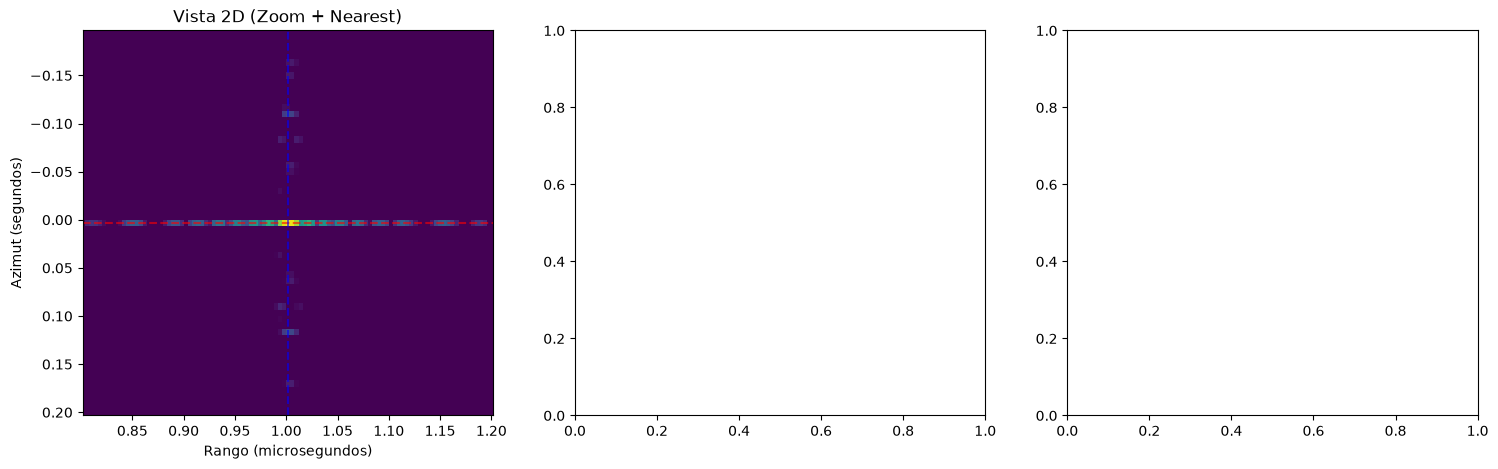

In [ ]:
# --- 8. ANÁLISIS DE LA FUNCIÓN DE RESPUESTA AL IMPULSO (IRF) ---

# 1. Buscamos las coordenadas del píxel más brillante en la matriz
idx_az, idx_rg = np.unravel_index(np.argmax(np.abs(imagen_final)), imagen_final.shape)

# 2. Extraemos los perfiles 1D en dB
corte_azimut = imagen_dB#[:, idx_rg]
corte_rango = imagen_dB#[idx_az, :]

# ====================================================================
# 3. CONVERSIÓN FÍSICA A METROS
rango_metros = t_rango * c / 2      # Distancia real (Slant Range)
azimut_metros = t_azimut * v        # Distancia real de vuelo
# ====================================================================

# --- PLOT: TABLERO IRF (3 PANELES) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel Izquierdo: Imagen 2D (Sigue en tiempos para referencia) ---
max_dB = np.max(imagen_dB)
ax1.imshow(imagen_dB, aspect='auto', cmap='viridis',
           extent=[rango_us[0], rango_us[-1], t_azimut[-1], t_azimut[0]],
           vmin=max_dB - 40, vmax=max_dB, interpolation='nearest')

ax1.set_xlim(rango_us[idx_rg] - 0.2, rango_us[idx_rg] + 0.2)
ax1.set_ylim(t_azimut[idx_az] + 0.2, t_azimut[idx_az] - 0.2)
ax1.axhline(y=t_azimut[idx_az], color='red', linestyle='--', alpha=0.6)
ax1.axvline(x=rango_us[idx_rg], color='blue', linestyle='--', alpha=0.6)
ax1.set_title('Vista 2D (Zoom + Nearest)')
ax1.set_xlabel('Rango (microsegundos)')
ax1.set_ylabel('Azimut (segundos)')

# --- Panel Central: Corte en Rango (AHORA EN METROS) ---
ax2.plot(rango_metros, corte_rango, color='blue', linewidth=1.5)
#ax2.axvline(x=rango_metros[idx_rg], color='red', linestyle='--', alpha=0.5, label='Pico Máximo')
# Hacemos un zoom de +/- 40 metros alrededor del blanco
ax2.set_xlim(rango_metros[idx_rg] - 40, rango_metros[idx_rg] + 40)
ax2.set_ylim(max_dB - 40, max_dB + 5)
ax2.set_title('IRF - Corte en Rango')
ax2.set_xlabel('Distancia de Rango (metros)')
ax2.set_ylabel('Amplitud (dB)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# --- Panel Derecho: Corte en Azimut (AHORA EN METROS) ---
ax3.plot(azimut_metros, corte_azimut, color='green', linewidth=1.5)
ax3.axvline(x=azimut_metros[idx_az], color='red', linestyle='--', alpha=0.5, label='Pico Máximo')
# Hacemos un zoom de +/- 200 metros alrededor del blanco
ax3.set_xlim(azimut_metros[idx_az] - 200, azimut_metros[idx_az] + 200)
ax3.set_ylim(max_dB - 60, max_dB + 5)
ax3.set_title('IRF - Corte en Azimut')
ax3.set_xlabel('Distancia de Azimut (metros)')
ax3.set_ylabel('Amplitud (dB)')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()